## Introduction

This is a sample notebook for using car pricing data to build a pricing model using a neural network. The initial data is pulled from kaggle sample dataset.

https://www.kaggle.com/datasets/deepcontractor/car-price-prediction-challenge/data


### Methodology

Initially I followed the sample notebook code in order to complete eda

Target variable is price of car: CarPrice


**Life Cycle of Machine Learning Project**

* Understanding the Problem Statement
* Data Checks to Perform
* Exploratory Data Analysis
* Data Pre-Processing
* Model Training
* Choose Best Model


**Problem Statement**

Predicting the price of cars based on a wide range of attributes and features. Using a dataset containing car details such as safety ratings, dimensions, engine specifications, and more, we aim to develop a machine learning model that accurately estimates the price of different car models.

In [5]:
## env is personal_projects Python 3.11.18
import os

import pandas as pd
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt


from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

import xgboost as xgb
from tabulate import tabulate
import scipy.stats as stats

import warnings
warnings.filterwarnings("ignore")

import kagglehub



In [9]:
## define some functions for eda
def column_summary(df):
    '''print summary of features for visualization'''
    summary_data = []
    for col_name in df.columns:
        col_dtype = df[col_name].dtype
        num_of_nulls = df[col_name].isnull().sum()
        num_of_non_nulls = df[col_name].notnull().sum()
        num_of_distinct_values = df[col_name].nunique()
        
        if num_of_distinct_values <= 10:
            distinct_values_counts = df[col_name].value_counts().to_dict()
        else:
            top_10_values_counts = df[col_name].value_counts().head(10).to_dict()
            distinct_values_counts = {k: v for k, v in sorted(top_10_values_counts.items(), 
                                                              key=lambda item: item[1], reverse=True)}

        summary_data.append({
            'col_name': col_name,
            'col_dtype': col_dtype,
            'num_of_nulls': num_of_nulls,
            'num_of_non_nulls': num_of_non_nulls,
            'num_of_distinct_values': num_of_distinct_values,
            'distinct_values_counts': distinct_values_counts
        })
    
    summary_df = pd.DataFrame(summary_data)
    return summary_df

In [6]:
# 1. Download the dataset
path = kagglehub.dataset_download("deepcontractor/car-price-prediction-challenge")

print("Path to dataset files:", path)

# 2. Check what the actual filename is
# This step is important because the filename might not be exactly 'CarPrice_Assignment.csv'
print("Files in this folder:", os.listdir(path))

# 3. Construct the full file path using the variable 'path'
# Replace 'car_price_prediction.csv' below with the actual filename you see printed above
csv_path = os.path.join(path, 'car_price_prediction.csv')

# 4. Load the dataframe
df = pd.read_csv(csv_path)

# 5. View the data
print(df.head())

Path to dataset files: /Users/danielburke/.cache/kagglehub/datasets/deepcontractor/car-price-prediction-challenge/versions/1
Files in this folder: ['car_price_prediction.csv']
         ID  Price  Levy Manufacturer    Model  Prod. year   Category  \
0  45654403  13328  1399        LEXUS   RX 450        2010       Jeep   
1  44731507  16621  1018    CHEVROLET  Equinox        2011       Jeep   
2  45774419   8467     -        HONDA      FIT        2006  Hatchback   
3  45769185   3607   862         FORD   Escape        2011       Jeep   
4  45809263  11726   446        HONDA      FIT        2014  Hatchback   

  Leather interior Fuel type Engine volume    Mileage  Cylinders  \
0              Yes    Hybrid           3.5  186005 km        6.0   
1               No    Petrol             3  192000 km        6.0   
2               No    Petrol           1.3  200000 km        4.0   
3              Yes    Hybrid           2.5  168966 km        4.0   
4              Yes    Petrol           1.3   

In [7]:
%whos DataFrame

Variable   Type         Data/Info
---------------------------------
df         DataFrame                 ID  Price  L<...>[19237 rows x 18 columns]


In [8]:
print(df.columns)

Index(['ID', 'Price', 'Levy', 'Manufacturer', 'Model', 'Prod. year',
       'Category', 'Leather interior', 'Fuel type', 'Engine volume', 'Mileage',
       'Cylinders', 'Gear box type', 'Drive wheels', 'Doors', 'Wheel', 'Color',
       'Airbags'],
      dtype='object')


In [10]:
display(column_summary(df))

,col_name,col_dtype,num_of_nulls,num_of_non_nulls,num_of_distinct_values,distinct_values_counts
0,ID,int64,0,19237,18924,"{45815365: 8, 45815361: 8, 45815363: 7, 458153..."
1,Price,int64,0,19237,2315,"{15681: 280, 470: 274, 14113: 244, 392: 242, 3..."
2,Levy,object,0,19237,559,"{'-': 5819, '765': 486, '891': 461, '639': 410..."
3,Manufacturer,object,0,19237,65,"{'HYUNDAI': 3769, 'TOYOTA': 3662, 'MERCEDES-BE..."
4,Model,object,0,19237,1590,"{'Prius': 1083, 'Sonata': 1079, 'Camry': 938, ..."
5,Prod. year,int64,0,19237,54,"{2012: 2155, 2014: 2124, 2013: 1963, 2011: 161..."
6,Category,object,0,19237,11,"{'Sedan': 8736, 'Jeep': 5473, 'Hatchback': 284..."
7,Leather interior,object,0,19237,2,"{'Yes': 13954, 'No': 5283}"
8,Fuel type,object,0,19237,7,"{'Petrol': 10150, 'Diesel': 4036, 'Hybrid': 35..."
9,Engine volume,object,0,19237,107,"{'2': 3916, '2.5': 2277, '1.8': 1760, '1.6': 1..."


## Data Checks and Cleaning

* Check data type
* Check the number of unique values of each column
* Check Missing values
* Check Duplicates
* Check statistics of the dataset
* Check various categories present in the different categorical columns

### Check Missing Values & Duplicates

There are no missing values in the dataset.

There are some duplicates I am going to inspect and then remove the first occurance, keeping the last one in each case.

In [15]:
duplicate_count = df.duplicated().sum()
print(f"Total duplicate rows: {duplicate_count}")

# 2. View the duplicate rows
# keep=False ensures you see ALL copies (the first occurrence AND the repeats)
duplicates = df[df.duplicated(keep=False)]

# Sort by a specific column (e.g., 'ID' or 'Price') so identical rows appear next to each other
# If you don't have an ID, sorting by 'Price' or another feature helps visual comparison
duplicates_sorted = duplicates.sort_values(by='Price') 

print("\n--- Duplicate Rows ---")
print(duplicates_sorted.head(10))

Total duplicate rows: 313

--- Duplicate Rows ---
             ID  Price  Levy Manufacturer   Model  Prod. year   Category  \
11988  45777718     30     -       TOYOTA   Prius        2007  Hatchback   
1818   45777718     30     -       TOYOTA   Prius        2007  Hatchback   
16620  45815359     47  1493        LEXUS  RX 350        2016       Jeep   
10264  45815359     47  1493        LEXUS  RX 350        2016       Jeep   
11525  45815359     47  1493        LEXUS  RX 350        2016       Jeep   
17027  45815359     47  1493        LEXUS  RX 350        2016       Jeep   
1370   45815359     47  1493        LEXUS  RX 350        2016       Jeep   
6776   45815359     47  1493        LEXUS  RX 350        2016       Jeep   
17300  44929665     50     -       TOYOTA    Aqua        2014      Sedan   
7788   44929665     50     -       TOYOTA    Aqua        2014      Sedan   

       Leather interior Fuel type Engine volume    Mileage  Cylinders  \
11988                 0       LPG       

In [16]:
# 1. (Optional) Check the size before dropping
print(f"Shape before: {df.shape}")

# 2. Drop duplicates, keeping the last (second) instance
df = df.drop_duplicates(keep='last')

# 3. Verify the change
print(f"Shape after: {df.shape}")

Shape before: (19237, 18)
Shape after: (18924, 18)


### Convert the two binaries into binary distributions

In [11]:
# Define your mappings based on your requirements
wheel_map = {'Left wheel': 1, 'Right-hand drive': 0}
leather_map = {'Yes': 1, 'No': 0}

# Apply the mapping
df['Wheel'] = df['Wheel'].map(wheel_map)
df['Leather interior'] = df['Leather interior'].map(leather_map)

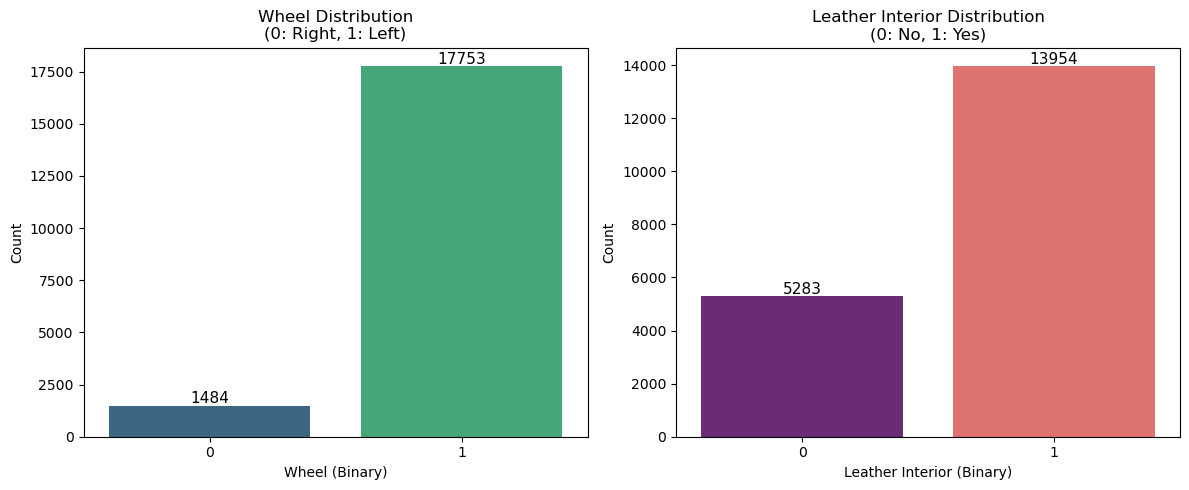

In [13]:
# Set up the matplotlib figure
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot Wheel Distribution
sns.countplot(x='Wheel', data=df, ax=axes[0], palette="viridis")
axes[0].set_title('Wheel Distribution\n(0: Right, 1: Left)')
axes[0].set_xlabel('Wheel (Binary)')
axes[0].set_ylabel('Count')
# Add count labels
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', fontsize=11, color='black', xytext=(0, 5),
                     textcoords='offset points')

# Plot Leather Distribution
sns.countplot(x='Leather interior', data=df, ax=axes[1], palette="magma")
axes[1].set_title('Leather Interior Distribution\n(0: No, 1: Yes)')
axes[1].set_xlabel('Leather Interior (Binary)')
axes[1].set_ylabel('Count')
# Add count labels
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', fontsize=11, color='black', xytext=(0, 5),
                     textcoords='offset points')

plt.tight_layout()

### Check the Distributions

Print a sample of the numerical distributions